In [1]:
setwd("~/Projects/R/ISLR2")

In [2]:
source("InstallAndLoadScripts/loadlibraries.R")

In [3]:
loadISLR2Libraries()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘ISLR2’


The following object is masked from ‘package:MASS’:

    Boston


Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘gridExtra’


The following object is mas

In [4]:
High = factor(ifelse(Carseats$Sales <= 8, "No", "Yes"))

In [5]:
Carseats = data.frame(Carseats, High)

In [6]:
tree.carseats = tree(High ~ . - Sales, Carseats)

In [7]:
summary(tree.carseats)


Classification tree:
tree(formula = High ~ . - Sales, data = Carseats)
Variables actually used in tree construction:
[1] "ShelveLoc"   "Price"       "Income"      "CompPrice"   "Population" 
[6] "Advertising" "Age"         "US"         
Number of terminal nodes:  27 
Residual mean deviance:  0.4575 = 170.7 / 373 
Misclassification error rate: 0.09 = 36 / 400 

In [8]:
deviance(tree.carseats, detail=T)

[1] 541.486837 390.591685  56.534305  12.217286   0.000000   6.730117
 [7]  35.467463  21.170024   7.940610 299.758669 213.232590  44.887998
[13]  33.148337  16.300638   0.000000   5.406735   8.477229   0.000000
[19] 150.181878  70.681403   6.701994  52.925059   7.481333  32.601277
[25]  16.048286   6.701994  55.542945  17.399411  25.008180  16.300638
[31]   5.741628   5.004024   0.000000  61.826542  25.020121  18.249184
[37]  12.365308   0.000000   0.000000  22.493406   0.000000  13.862944
[43]   0.000000   0.000000  90.327606  49.260636  22.074444   0.000000
[49]  11.457255  16.875237  22.074444   0.000000  15.158203

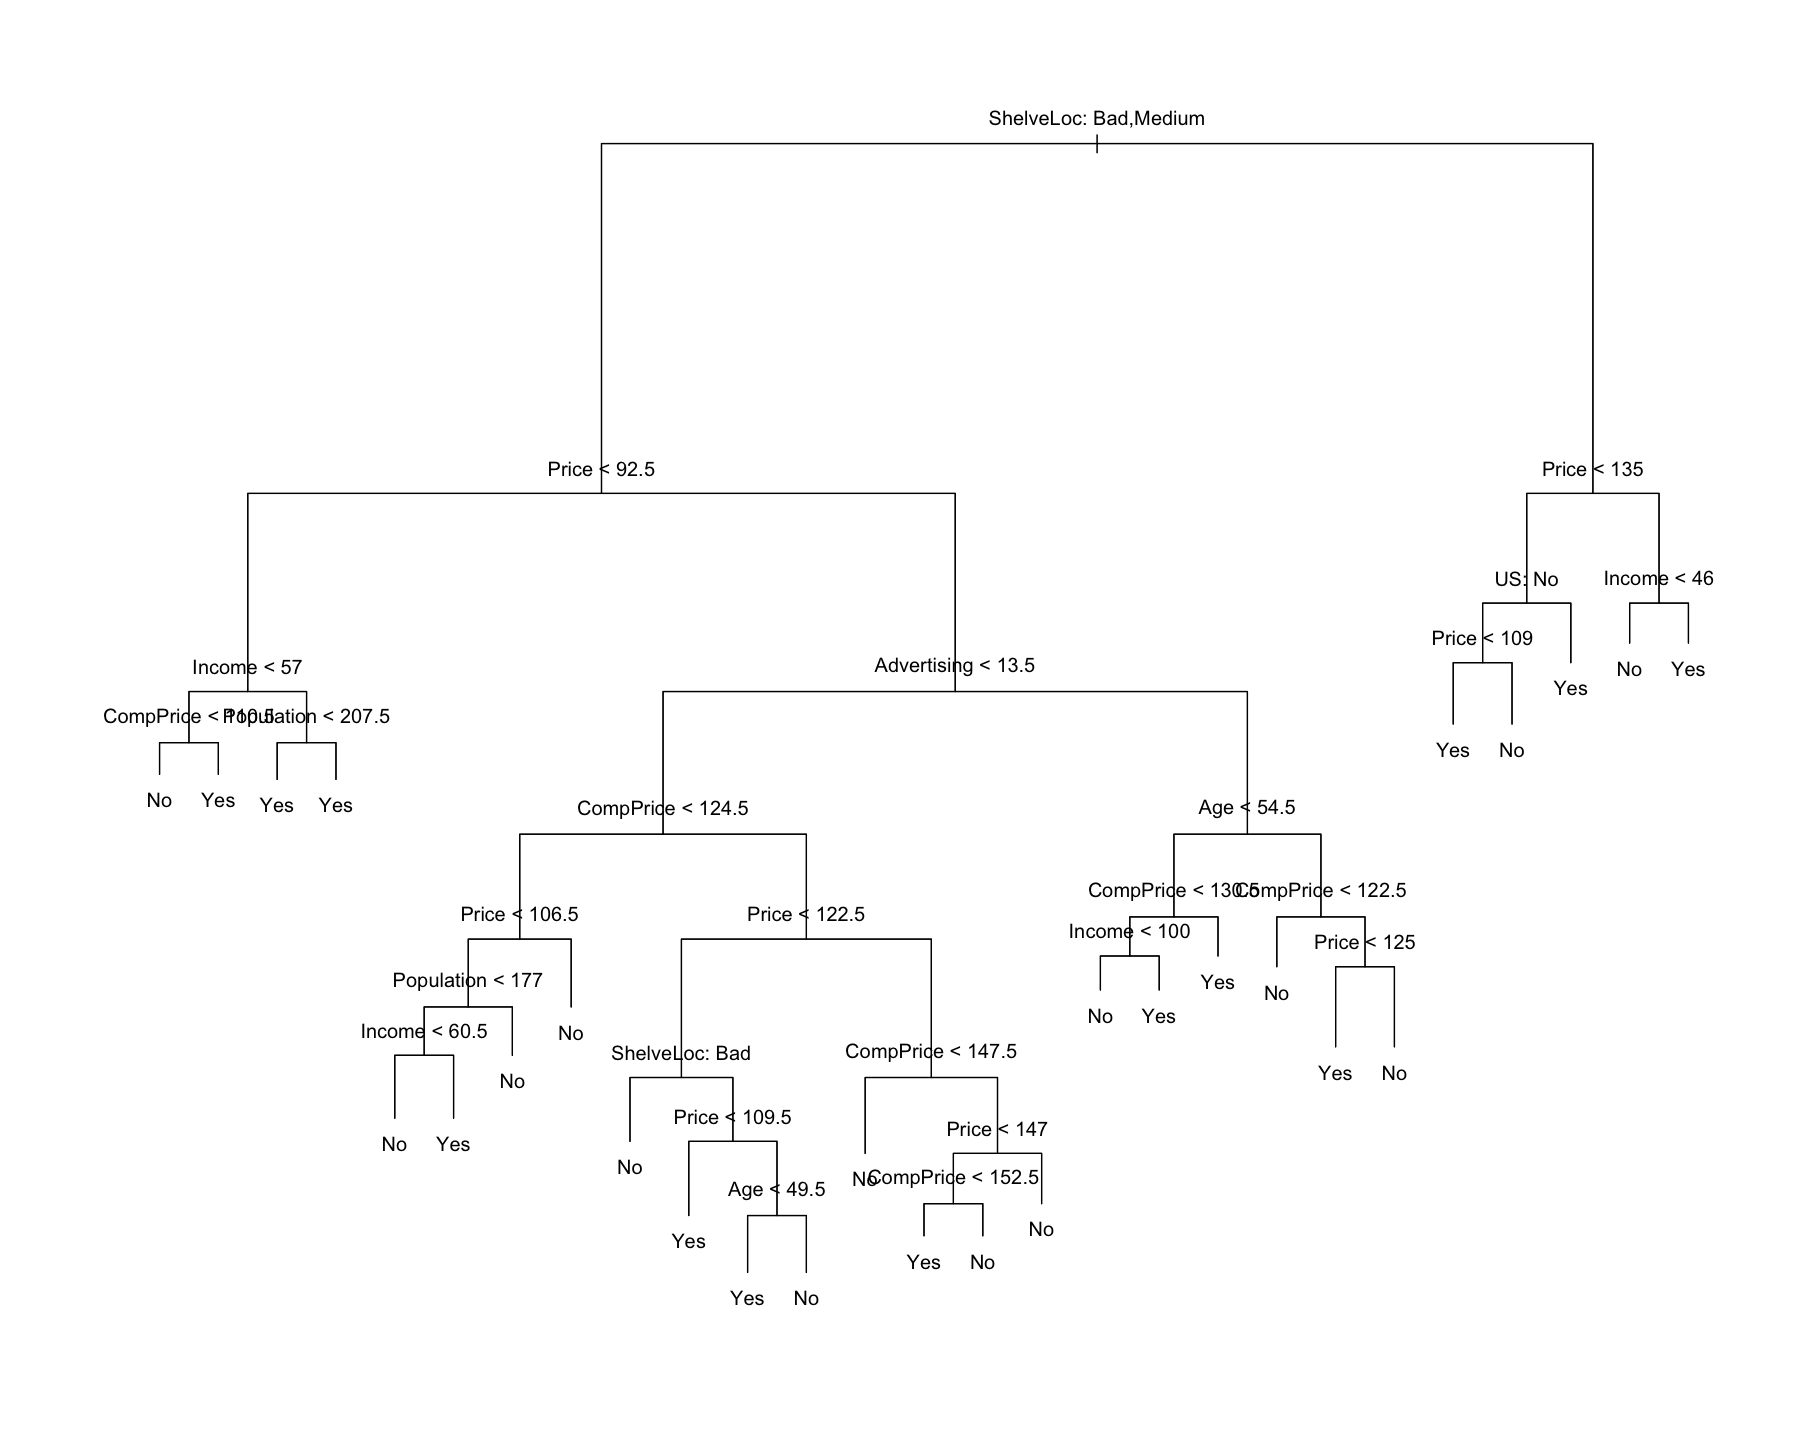

In [9]:
plot(tree.carseats)
text(tree.carseats, pretty = 0)

In [10]:
tree.carseats

node), split, n, deviance, yval, (yprob)
      * denotes terminal node

  1) root 400 541.500 No ( 0.59000 0.41000 )  
    2) ShelveLoc: Bad,Medium 315 390.600 No ( 0.68889 0.31111 )  
      4) Price < 92.5 46  56.530 Yes ( 0.30435 0.69565 )  
        8) Income < 57 10  12.220 No ( 0.70000 0.30000 )  
         16) CompPrice < 110.5 5   0.000 No ( 1.00000 0.00000 ) *
         17) CompPrice > 110.5 5   6.730 Yes ( 0.40000 0.60000 ) *
        9) Income > 57 36  35.470 Yes ( 0.19444 0.80556 )  
         18) Population < 207.5 16  21.170 Yes ( 0.37500 0.62500 ) *
         19) Population > 207.5 20   7.941 Yes ( 0.05000 0.95000 ) *
      5) Price > 92.5 269 299.800 No ( 0.75465 0.24535 )  
       10) Advertising < 13.5 224 213.200 No ( 0.81696 0.18304 )  
         20) CompPrice < 124.5 96  44.890 No ( 0.93750 0.06250 )  
           40) Price < 106.5 38  33.150 No ( 0.84211 0.15789 )  
             80) Population < 177 12  16.300 No ( 0.58333 0.41667 )  
              160) Income < 60.5 6   0

In [11]:
deviance(tree.carseats)

[1] 170.6594

In [12]:
deviance(tree.carseats, detail=T)[1:10]

[1] 541.486837 390.591685  56.534305  12.217286   0.000000   6.730117
 [7]  35.467463  21.170024   7.940610 299.758669

In [45]:
set.seed(2)
write.csv(Carseats, file = "/Users/rob/Projects/R/ISLR2/data/Carseats_all.csv")
train = sample(1:nrow(Carseats), 300)
Carseats.test = Carseats[-train, ]
write.csv(Carseats.test, file = "/Users/rob/Projects/R/ISLR2/data/Carseats_test.csv")
Carseats.train = Carseats[train, ]
write.csv(Carseats.train, file = "/Users/rob/Projects/R/ISLR2/data/Carseats_train.csv")

High.test = High[-train]
tree.carseats = tree(High ~ . - Sales, Carseats, subset=train)
tree.pred = predict(tree.carseats, Carseats.test, type="class")
table(tree.pred, High.test)

         High.test
tree.pred No Yes
      No  48   7
      Yes 15  30

In [46]:
(48+30)/100

[1] 0.78

In [15]:
set.seed(7)
cv.carseats = cv.tree(tree.carseats, FUN=prune.misclass)

In [16]:
names(cv.carseats)

[1] "size"   "dev"    "k"      "method"

In [17]:
cv.carseats

$size
[1] 26 22 20 17 12  9  4  2  1

$dev
[1]  76  76  76  81  85  88  89  95 127

$k
[1]      -Inf  0.000000  0.500000  2.000000  2.400000  2.666667  3.000000
[8] 10.500000 35.000000

$method
[1] "misclass"

attr(,"class")
[1] "prune"         "tree.sequence"

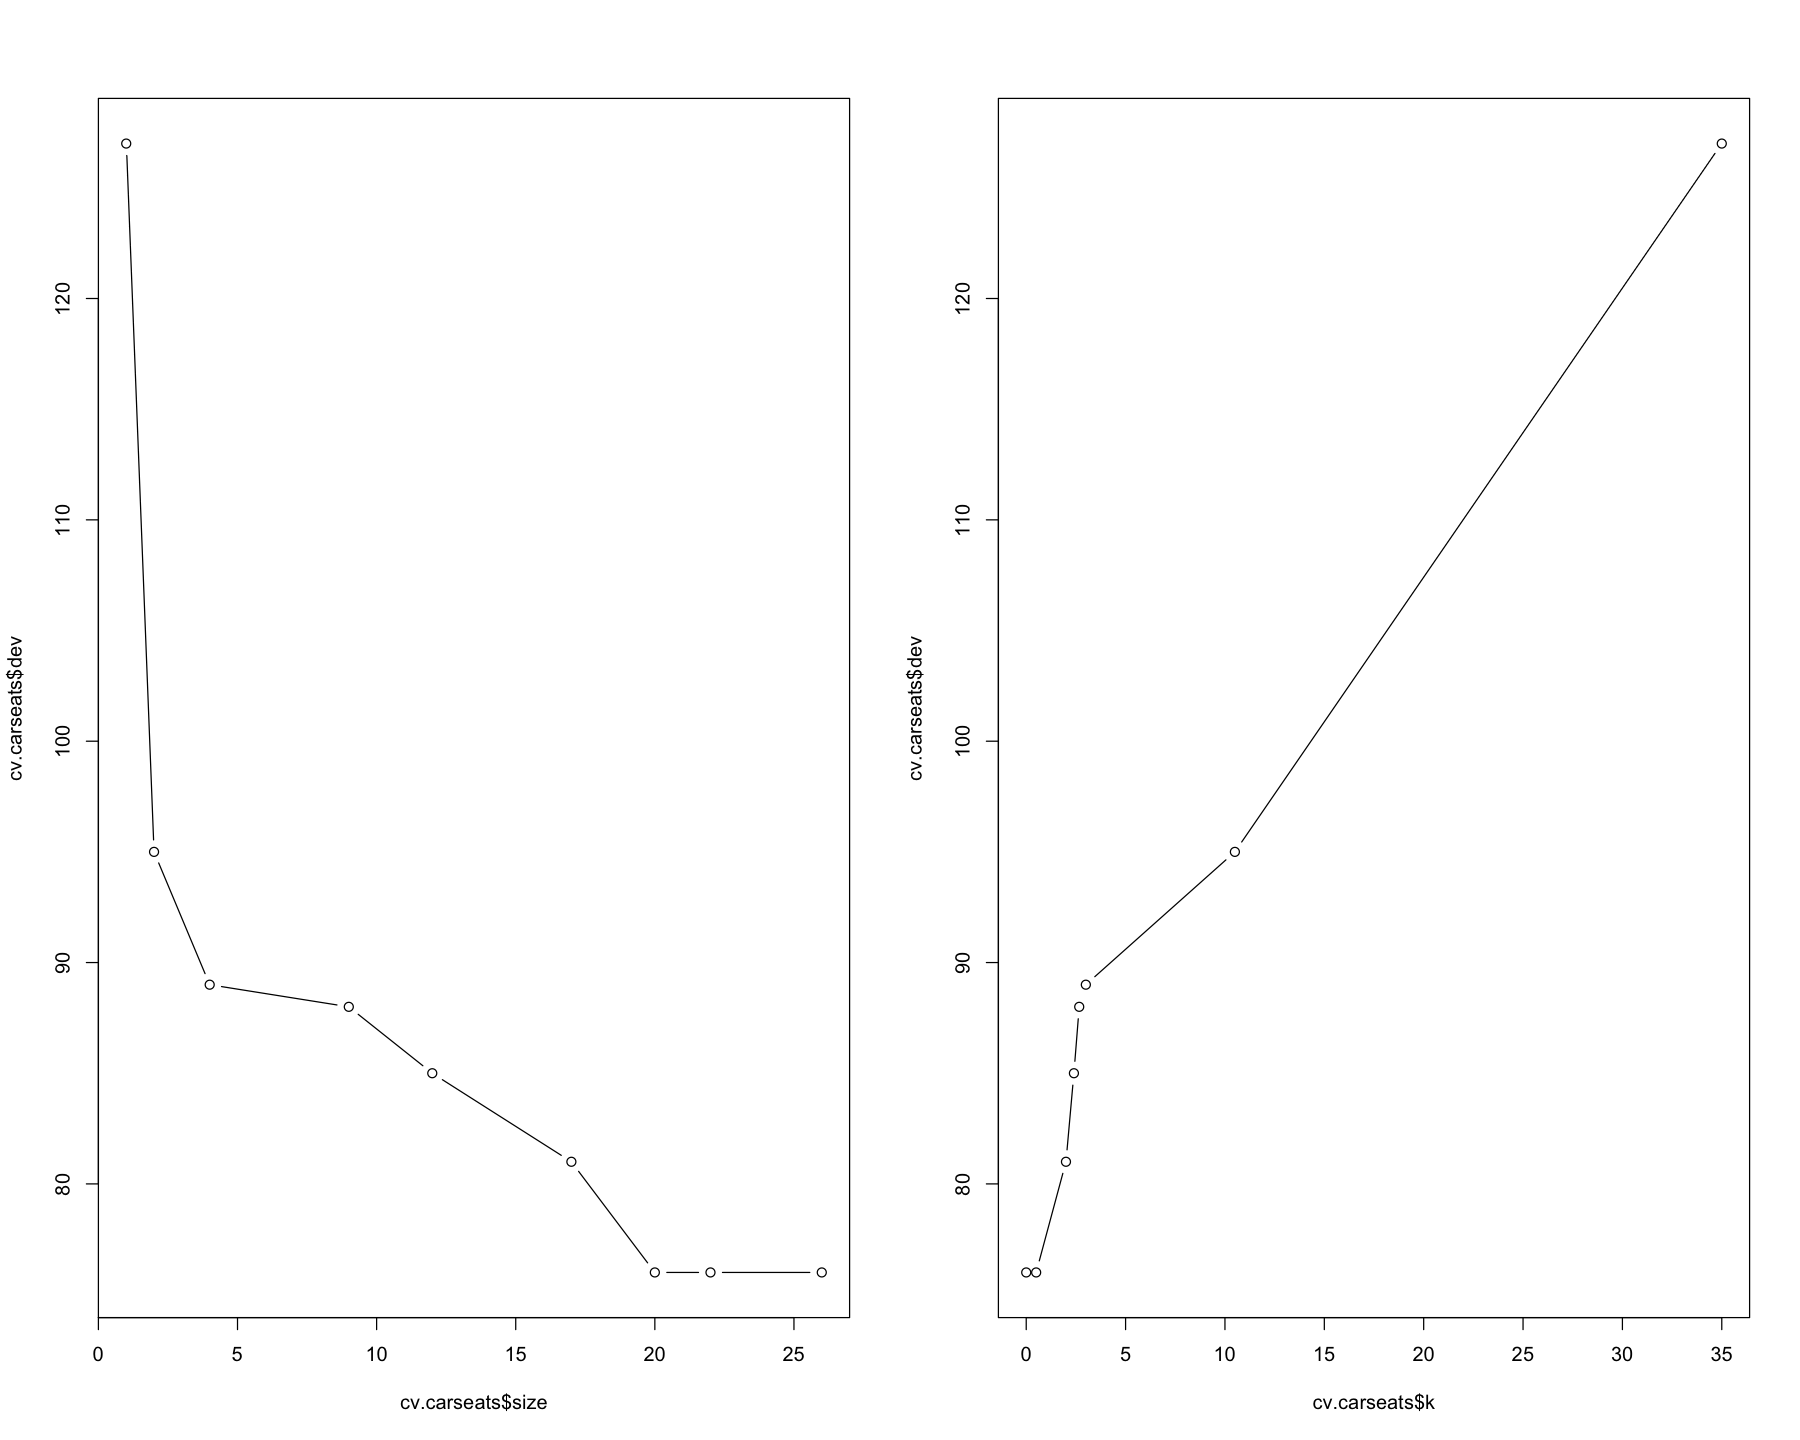

In [18]:
par(mfrow=c(1,2))
plot(cv.carseats$size, cv.carseats$dev, type="b")
plot(cv.carseats$k, cv.carseats$dev, type="b")

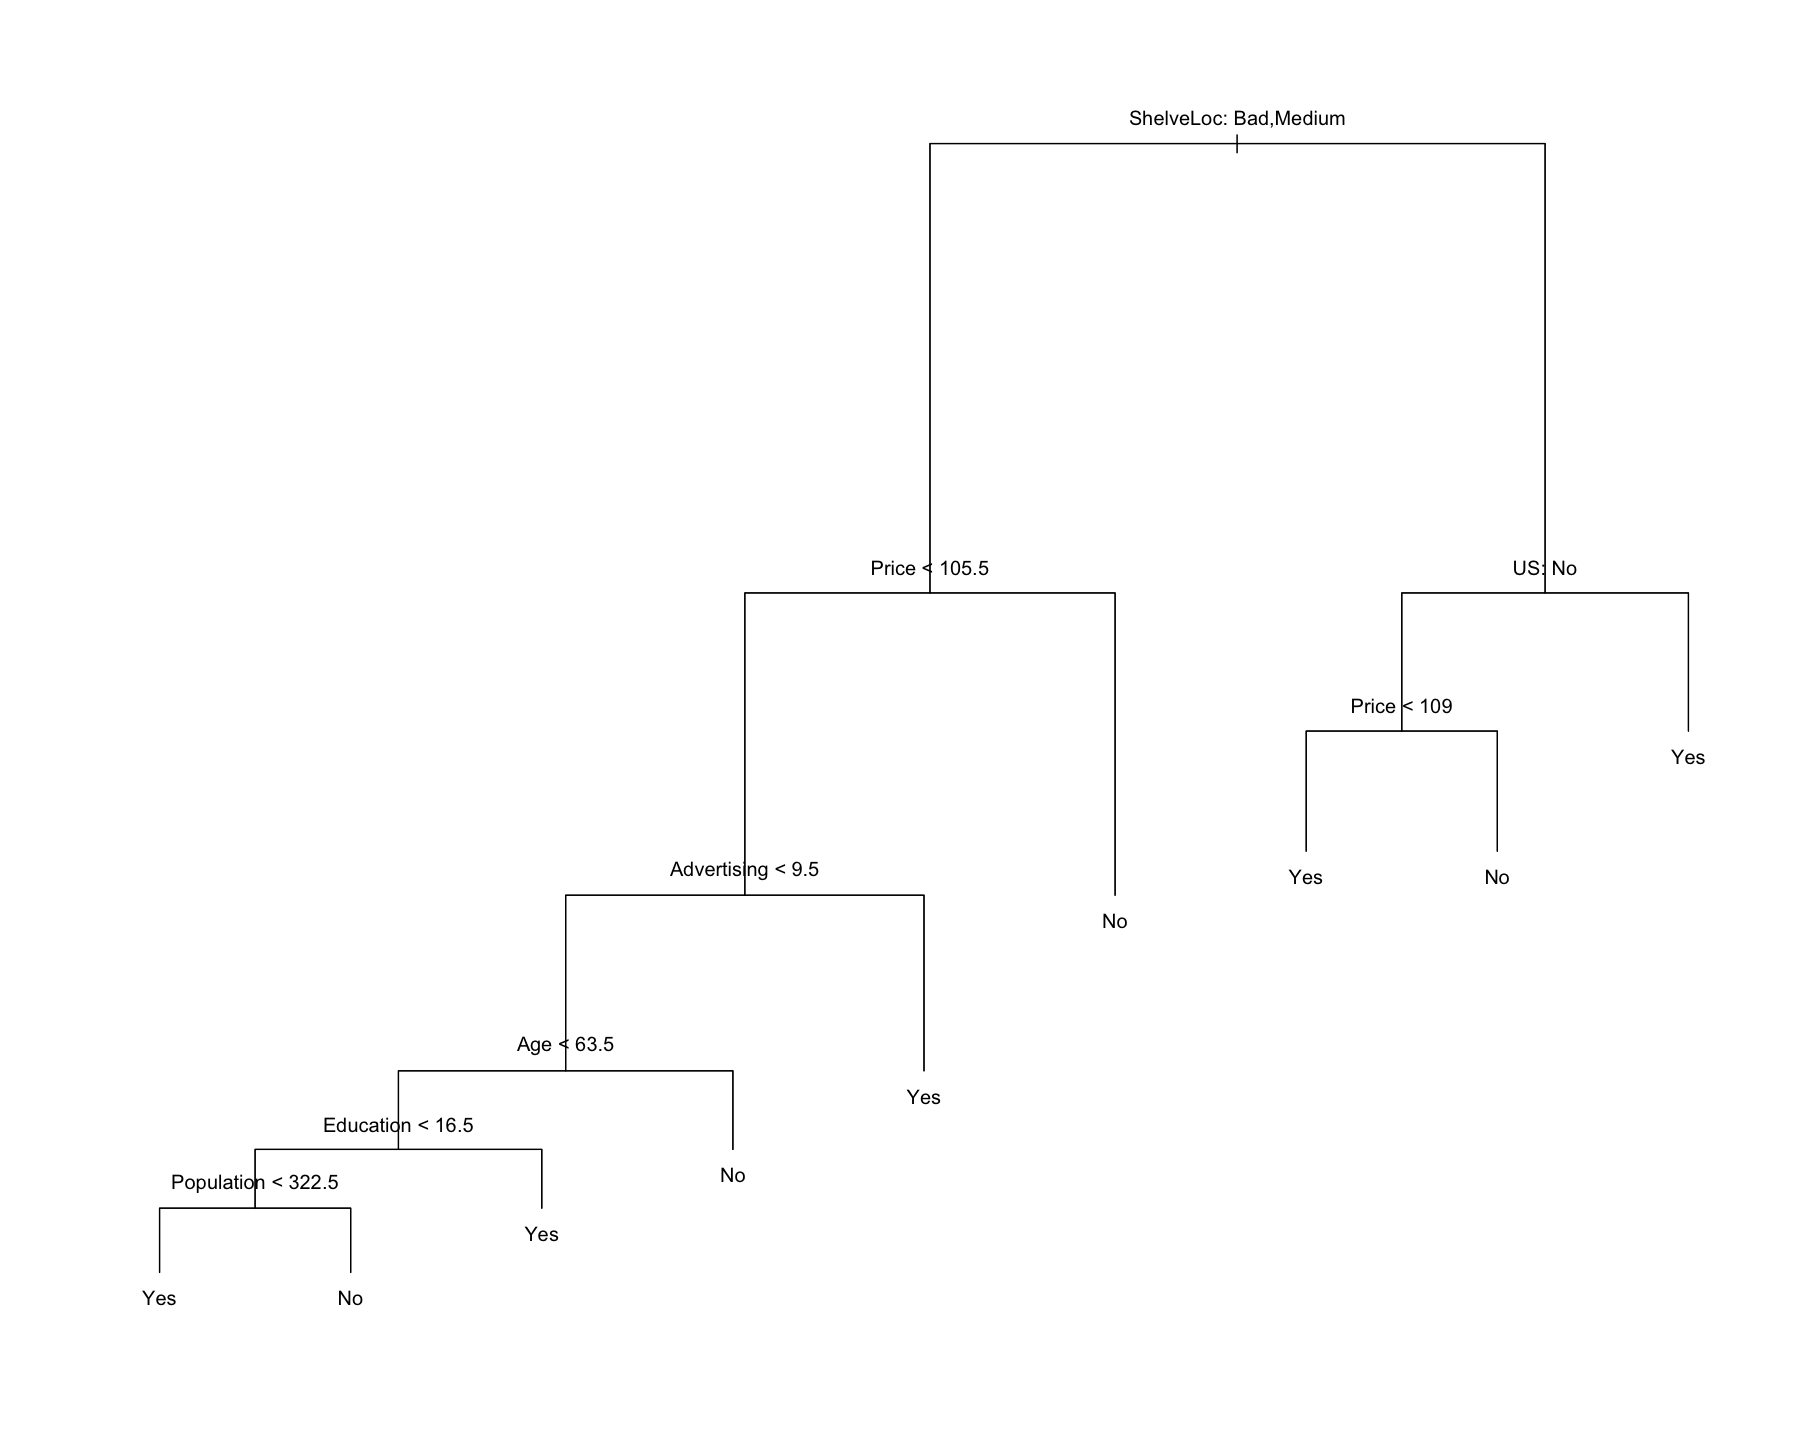

In [19]:
prune.carseats = prune.misclass(tree.carseats, best=9)
plot(prune.carseats)
text(prune.carseats, pretty=0)

In [20]:
prune.carseats

node), split, n, deviance, yval, (yprob)
      * denotes terminal node

 1) root 300 408.800 No ( 0.57667 0.42333 )  
   2) ShelveLoc: Bad,Medium 241 306.300 No ( 0.66805 0.33195 )  
     4) Price < 105.5 82 112.500 Yes ( 0.43902 0.56098 )  
       8) Advertising < 9.5 51  68.310 No ( 0.60784 0.39216 )  
        16) Age < 63.5 32  44.240 Yes ( 0.46875 0.53125 )  
          32) Education < 16.5 24  32.600 No ( 0.58333 0.41667 )  
            64) Population < 322.5 15  20.190 Yes ( 0.40000 0.60000 ) *
            65) Population > 322.5 9   6.279 No ( 0.88889 0.11111 ) *
          33) Education > 16.5 8   6.028 Yes ( 0.12500 0.87500 ) *
        17) Age > 63.5 19  16.570 No ( 0.84211 0.15789 ) *
       9) Advertising > 9.5 31  27.390 Yes ( 0.16129 0.83871 ) *
     5) Price > 105.5 159 165.000 No ( 0.78616 0.21384 ) *
   3) ShelveLoc: Good 59  59.600 Yes ( 0.20339 0.79661 )  
     6) US: No 18  24.950 Yes ( 0.50000 0.50000 )  
      12) Price < 109 6   0.000 Yes ( 0.00000 1.00000 ) *
      

In [21]:
tree.pred = predict(prune.carseats, Carseats.test,
                    type="class")
table(tree.pred, High.test)

         High.test
tree.pred No Yes
      No  48   9
      Yes 15  28

In [1]:
(48+28)/100

[1] 0.76